# 1. Setup and Dataset Processing

In [1]:
from google.colab import drive
import os, sys
from pathlib import Path

drive.mount('/content/drive')

# project_path = "/content/drive/MyDrive/Flinders_NN/research_graph_gan_v4"
project_path = "/content/drive/Othercomputers/My laptop/research_notbooks/research_graph_gan_v4"
# project_path = Path.cwd()

os.chdir(project_path)
sys.path.append(str(Path(project_path).parent))

Mounted at /content/drive


In [2]:
%pip install torchinfo
%pip install torch_geometric

import random

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data_utils

from torchinfo import summary

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

compute_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {compute_device}')
print(f'torch version: {torch.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.3 MB/s eta 0:00:00
Using device: cuda
torch version: 2.10.0+cu128


## Build graph

Dummy KG built: 10 entities, 3 relations, 18 directed edges
Tensor shape: (10, 10, 3)  (N, N, R)
Density: 0.0667
Entity IDs: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]  (non-trivial, offset=100)
Relation IDs: [50, 51, 52]  (non-trivial, offset=50)
num_nodes=10, num_channels=3


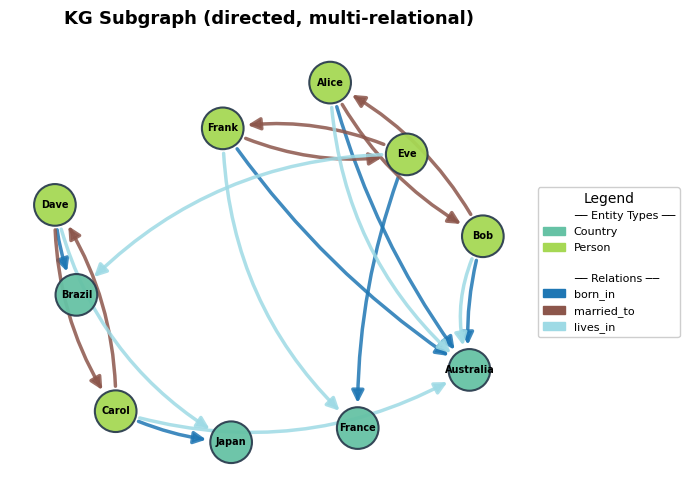

In [3]:
from build_graphs import build_dummy_kg, get_dummy_kg_metadata, visualise_kg_subgraph

# Same return signature as build_kg_subgraph()
adjacency_tensor, entity_id_to_row, relation_id_to_channel = build_dummy_kg()
relation_id_to_name, entity_id_to_name, node_labels, node_types = get_dummy_kg_metadata()

num_nodes    = adjacency_tensor.shape[0]   # N = 10
num_channels = adjacency_tensor.shape[2]   # R = 3

print(f'num_nodes={num_nodes}, num_channels={num_channels}')

# Visualise
visualise_kg_subgraph(
    adjacency_tensor,
    entity_id_to_row,
    relation_id_to_channel,
    relation_id_to_name,
    node_labels=node_labels,
    node_types=node_types,
    figsize=(7, 5),
)


# 2. Build Dataset



In [4]:
import functools
from corruption_strategies import apply_tric_corruption
from dataset_builders import build_kg_paired_dataset

# Hyperparameters
num_corruptions    = 2
num_training_pairs = 4000
dataset_rng        = np.random.default_rng(random_seed)

# Corruption strategy: only change_relation — keeps (subject, object) fixed,
# swaps the relation type.  Example: born_in(Alice, Australia) → married_to(Alice, Australia).
# This is TRIC type 3.  Pass op_weights to restrict to a single operation.
tric_fn = functools.partial(
    apply_tric_corruption,
    node_types=node_types,
    op_weights={'change_relation': 1},
)

# Build (B, R, N, N) paired tensors in [-1, 1]; permutations applied to N axes only
clean_pairs, corrupted_pairs, permutations_list = build_kg_paired_dataset(
    adjacency_tensor, num_training_pairs, num_corruptions, dataset_rng,
    corruption_fn=tric_fn,
)

# Sanity checks
assert clean_pairs.shape == (num_training_pairs, num_channels, num_nodes, num_nodes), \
    f'Expected ({num_training_pairs}, {num_channels}, {num_nodes}, {num_nodes}), got {clean_pairs.shape}'
# In [-1, 1] encoding: no-edge = -1, edge = +1.  Diagonal must be -1 (no self-loops), never +1.
diag_vals = clean_pairs[:, :, torch.arange(num_nodes), torch.arange(num_nodes)]
assert diag_vals.max() < 0.99, 'Self-loops detected in dataset'

edges_per_sample = ((clean_pairs + 1.0) / 2.0).sum(dim=(1, 2, 3))
print(f'Dataset: {clean_pairs.shape}  (B, R, N, N),  values in [-1, 1]')
print(f'Edges per clean sample: mean={edges_per_sample.mean():.1f}, std={edges_per_sample.std():.1f}')

# Verify change_relation produces net-zero edge delta (swap, not deletion)
corrupted_edges = ((corrupted_pairs + 1.0) / 2.0).sum(dim=(1, 2, 3))
net_delta = corrupted_edges - edges_per_sample
print(f'Net edge delta per corrupted sample: mean={net_delta.mean():.2f}, '
      f'std={net_delta.std():.2f}  (should be ~0.0 for pure relation swaps)')


Dataset: torch.Size([4000, 3, 10, 10])  (B, R, N, N),  values in [-1, 1]
Edges per clean sample: mean=18.0, std=0.0
Net edge delta per corrupted sample: mean=0.00, std=0.00  (should be ~0.0 for pure relation swaps)


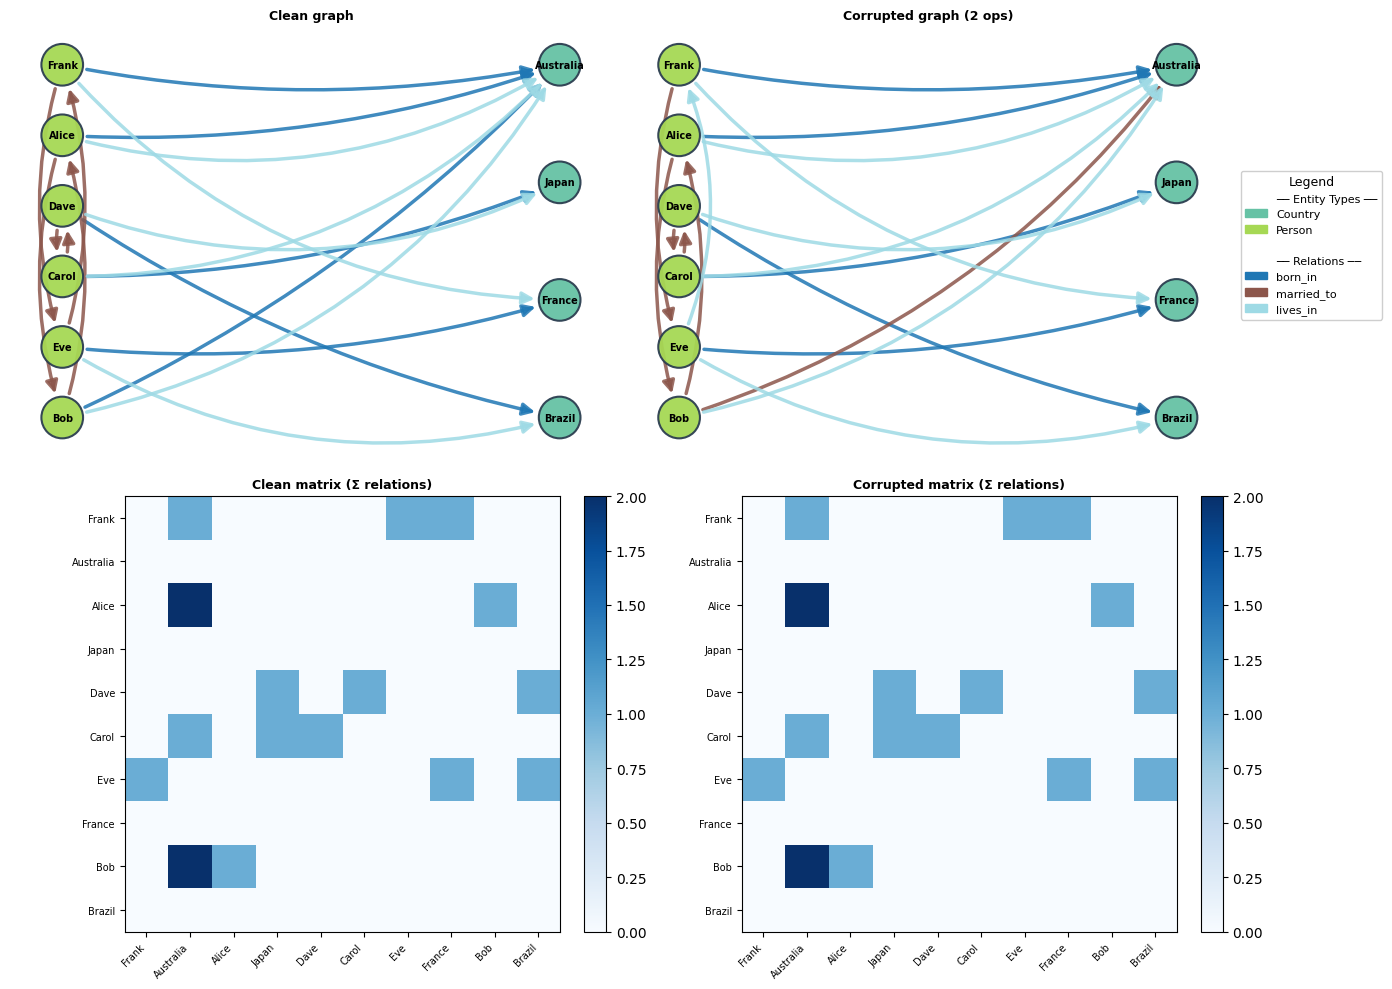

  Channel 0 (born_in): 6 clean → 5 corrupted edges
  Channel 1 (married_to): 6 clean → 6 corrupted edges
  Channel 2 (lives_in): 6 clean → 7 corrupted edges


In [5]:
from visualisation import plot_dataset_sample

example_idx = 0
clean_cf = clean_pairs[example_idx]   # (R, N, N) in [-1, 1]
corr_cf  = corrupted_pairs[example_idx]

# Convert to (N, N, R) float in [0, 1] — format expected by the visualisation package
clean_nxnxr = ((clean_cf + 1.0) / 2.0).numpy().transpose(1, 2, 0)
corr_nxnxr  = ((corr_cf  + 1.0) / 2.0).numpy().transpose(1, 2, 0)

# Recover permutation for this sample: perm[k] = original node at row k after shuffle
# int() is required because perm elements are tensor scalars, not plain Python ints
perm = permutations_list[example_idx]
permuted_labels = {k: node_labels[int(perm[k])] for k in range(num_nodes)}
permuted_types  = {k: node_types[int(perm[k])]  for k in range(num_nodes)}

# Relation names ordered by channel index
relation_names = [relation_id_to_name[rid]
                  for rid in sorted(relation_id_to_channel, key=relation_id_to_channel.get)]

plot_dataset_sample(
    clean_nxnxr, corr_nxnxr,
    permuted_labels, permuted_types,
    relation_names, num_corruptions=num_corruptions,
)

# Per-channel edge counts
for r in range(num_channels):
    clean_r = int(((clean_cf[r] + 1.0) / 2.0).sum())
    corr_r  = int(((corr_cf[r]  + 1.0) / 2.0).sum())
    print(f'  Channel {r} ({relation_names[r]}): {clean_r} clean → {corr_r} corrupted edges')


## Build dataloader

In [6]:
# Pairs from build_kg_paired_dataset are already (B, R, N, N) in [-1, 1] — no reshaping needed
clean_tensor_rescaled     = clean_pairs
corrupted_tensor_rescaled = corrupted_pairs

paired_dataset = data_utils.TensorDataset(clean_tensor_rescaled, corrupted_tensor_rescaled)

training_batch_size = 64
paired_dataloader = data_utils.DataLoader(
    paired_dataset, batch_size=training_batch_size, shuffle=True, drop_last=True
)

print(f'Dataset: {len(paired_dataset)} pairs')
print(f'Batches per epoch: {len(paired_dataloader)}')
print(f'Clean tensor shape: {clean_tensor_rescaled.shape}  (B, R, N, N)')
print(f'Tensor range: [{clean_tensor_rescaled.min():.1f}, {clean_tensor_rescaled.max():.1f}]  (-1=no edge, +1=edge)')


Dataset: 4000 pairs
Batches per epoch: 62
Clean tensor shape: torch.Size([4000, 3, 10, 10])  (B, R, N, N)
Tensor range: [-1.0, 1.0]  (-1=no edge, +1=edge)


# 3. Conditional GAN Architecture

**Generator — clean_adjacency → corrupted_adjacency.** Encoder–decoder built from
Conv2d (downsampling) and ConvTranspose2d (upsampling). Dropout layers stay active
at inference time to provide stochasticity (Pix2Pix convention — no explicit noise input).
A residual connection adds the input back to the decoder output so the generator
only has to learn the *difference* (which edges to remove).

**Discriminator — (clean, candidate) pair → real/fake score.** Takes a 2-channel
input by stacking the clean and candidate adjacencies along the channel dimension.
This is what enforces the conditional link: the discriminator's decision depends on
both inputs jointly.

Both networks use spatial sizes derived from `num_nodes`, so the code works for any
graph size without manual rewiring (same dynamic-sizing trick as the original notebook).


In [7]:
# =============================================================================
# MODEL ARCHITECTURE HYPERPARAMETERS
# =============================================================================

# num_nodes and num_channels are set in the load-graph cell from adjacency_tensor.shape.
# num_channels = R = 3 (one per relation type in the dummy KG).

# Base channel count for both Generator and Discriminator convolution layers.
# With R=3 input channels, feature_depth=24 is a reasonable starting point.
# For R=20 (FB15k-237), consider reducing to 16 to limit parameter growth.
feature_depth = 24

generator_dropout_rate    = 0.3
leaky_relu_negative_slope = 0.2


def weights_init(module):
    """DCGAN weight init - Normal(0, 0.02) for Conv layers and any affine norm.

    NOTE for the baseline: applied to the generator ONLY. The discriminator's
    Conv2d layers are wrapped in nn.utils.spectral_norm (see PairDiscriminator),
    which replaces the `.weight` attribute with a normalized projection
    recomputed from `.weight_orig` at every forward pass. Calling
    `module.weight.data = ...` on a spectral-norm Conv2d would target a
    non-parameter attribute and silently no-op. So we skip the discriminator
    and rely on PyTorch's default Kaiming init for weight_orig.
    """
    class_name = module.__class__.__name__
    if 'Conv' in class_name:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif 'Norm' in class_name and hasattr(module, 'weight') and module.weight is not None:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        if module.bias is not None:
            nn.init.constant_(module.bias.data, 0)


class ConditionalCorruptionGenerator(nn.Module):
    """U-Net encoder-decoder with logit-space residual edit.

    Architecture follows pix2pix (Isola et al., CVPR 2018):
      - U-Net skip connections pass low-level edge structure directly from
        encoder to decoder, bypassing the bottleneck.
      - Dropout stays active at inference time as the sole noise source
        (no explicit z input - pix2pix S3.1 convention).
      - Logit-space residual: generator learns what to CHANGE, not the
        full output from scratch. Appropriate for KG corruption (small edits).
    """

    def __init__(self, spatial_size, channels=1, base_depth=32, dropout_rate=0.3):
        super().__init__()
        self.spatial_size = spatial_size

        # -- Encoder stages (kept separate so we can skip-connect them) ------
        self.enc1 = nn.Sequential(
            nn.Conv2d(channels, base_depth, kernel_size=4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(base_depth, affine=True),
            nn.LeakyReLU(leaky_relu_negative_slope, inplace=True),
        )  # (B, D, N/2, N/2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(base_depth, base_depth * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(base_depth * 2, affine=True),
            nn.LeakyReLU(leaky_relu_negative_slope, inplace=True),
            nn.Conv2d(base_depth * 2, base_depth * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(base_depth * 2, affine=True),
            nn.LeakyReLU(leaky_relu_negative_slope, inplace=True),
        )  # (B, 2D, N/2, N/2)

        # -- Bottleneck - enc2 output is compressed here; enc2 skip bypasses it --
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_depth * 2, base_depth * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(base_depth * 2, affine=True),
            nn.Dropout2d(dropout_rate),
            nn.ReLU(inplace=True),
        )  # (B, 2D, N/2, N/2)

        # -- Decoder stages (skip connections double the input channels) -----
        # dec1 input: bottleneck output + enc2 skip = 2D + 2D = 4D channels
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_depth * 4, base_depth, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(base_depth, affine=True),
            nn.Dropout2d(dropout_rate),
            nn.ReLU(inplace=True),
        )  # (B, D, N/2, N/2)

        # dec2 input: dec1 upsampled + enc1 skip = D + D = 2D channels
        self.dec2 = nn.ConvTranspose2d(
            base_depth * 2, channels, kernel_size=4, stride=2, padding=1, bias=True
        )  # (B, C, N, N)

        # 1x1 projection: maps decoder output to a logit-space edit delta.
        # DCGAN init (not zeros) so gradients flow from the first batch.
        self.size_correction = nn.Conv2d(channels, channels, kernel_size=1)
        nn.init.normal_(self.size_correction.weight.data, 0.0, 0.02)
        nn.init.zeros_(self.size_correction.bias)

    def forward(self, clean_input):
        # clean_input: (B, R, N, N) in [-1, 1]
        clean_prob  = (clean_input + 1.0) / 2.0
        eps         = 1e-4
        clean_logit = torch.log(clean_prob.clamp(eps, 1 - eps) /
                                (1 - clean_prob.clamp(eps, 1 - eps)))

        # -- Encode -----------------------------------------------------------
        e1 = self.enc1(clean_input)   # (B, D,  N/2, N/2)
        e2 = self.enc2(e1)            # (B, 2D, N/2, N/2)

        # -- Bottleneck -------------------------------------------------------
        bt = self.bottleneck(e2)      # (B, 2D, N/2, N/2)

        # -- Decode with U-Net skip connections ------------------------------
        # e2 skips AROUND the bottleneck into dec1; e1 skips into dec2
        d1    = self.dec1(torch.cat([bt, e2], dim=1))                                       # (B, D,  N/2, N/2)
        d1_up = nn.functional.interpolate(d1, size=e1.shape[2:], mode='bilinear', align_corners=False)
        decoded = self.dec2(torch.cat([d1_up, e1], dim=1))                                  # (B, C,  N,   N)

        n = self.spatial_size
        if decoded.shape[-2:] != (n, n):
            decoded = nn.functional.interpolate(decoded, size=(n, n), mode='bilinear', align_corners=False)

        # -- Logit-space residual edit ----------------------------------------
        edit_logit     = self.size_correction(decoded)
        combined_logit = clean_logit + edit_logit   # generator learns delta, not full output

        # -- Hard-zero diagonal (no self-loops for any relation) -------------
        diag_mask      = torch.eye(n, device=combined_logit.device).unsqueeze(0).unsqueeze(0)
        combined_logit = combined_logit * (1 - diag_mask) + (-10.0) * diag_mask

        prob   = torch.sigmoid(combined_logit)   # (B, R, N, N) in [0, 1]
        output = prob * 2.0 - 1.0               # rescale to [-1, 1]
        return output, prob, combined_logit


class PairDiscriminator(nn.Module):
    """Conditional PatchGAN discriminator WITH spectral normalisation.

    Baseline-stabilisation change: every Conv2d is wrapped in
    `nn.utils.spectral_norm` (Miyato et al., ICLR 2018). Spectral norm
    constrains each layer's operator norm to <=1, capping D's overall
    Lipschitz constant. This directly attacks the failure mode the unstable
    baseline exhibited (cell 15 notes): D becomes overconfident, loss
    collapses to ~0, D(real)/D(fake) saturate at the extremes. With its
    Lipschitz constant bounded, D cannot drive its logits arbitrarily large
    and the BCE saturation goes away.

    Everything else is unchanged from the original PatchGAN: clean +
    candidate concatenated along channels (conditional input), three
    InstanceNorm + LeakyReLU conv blocks, final 3x3 conv producing
    per-patch logits. The final layer is ALSO wrapped - without it, the
    last linear projection can still amplify unboundedly.
    """

    def __init__(self, spatial_size, channels=1, base_depth=32):
        super().__init__()
        paired_input_channels = channels * 2   # clean + candidate stacked
        self.net = nn.Sequential(
            nn.utils.spectral_norm(
                nn.Conv2d(paired_input_channels, base_depth, kernel_size=3, stride=1, padding=1)),
            nn.LeakyReLU(leaky_relu_negative_slope, inplace=True),

            nn.utils.spectral_norm(
                nn.Conv2d(base_depth, base_depth * 2, kernel_size=3, stride=2, padding=1)),
            nn.InstanceNorm2d(base_depth * 2, affine=True),
            nn.LeakyReLU(leaky_relu_negative_slope, inplace=True),

            nn.utils.spectral_norm(
                nn.Conv2d(base_depth * 2, base_depth * 2, kernel_size=3, stride=1, padding=1)),
            nn.InstanceNorm2d(base_depth * 2, affine=True),
            nn.LeakyReLU(leaky_relu_negative_slope, inplace=True),

            # 3x3 final conv - local patch context vs 1x1 PixelGAN (pix2pix Table 3)
            nn.utils.spectral_norm(
                nn.Conv2d(base_depth * 2, 1, kernel_size=3, stride=1, padding=1)),
        )

    def forward(self, clean_input, candidate_input):
        paired = torch.cat([clean_input, candidate_input], dim=1)
        return self.net(paired)   # (B, 1, H', W') raw logits


generator_model = ConditionalCorruptionGenerator(
    spatial_size=num_nodes,
    channels=num_channels,
    base_depth=feature_depth,
    dropout_rate=generator_dropout_rate,
).to(compute_device)

discriminator_model = PairDiscriminator(
    spatial_size=num_nodes,
    channels=num_channels,
    base_depth=feature_depth,
).to(compute_device)

# DCGAN init for the generator only. The discriminator uses spectral_norm,
# whose weight is a forward-computed projection of weight_orig - direct
# assignment to .weight.data is a silent no-op. weight_orig keeps PyTorch's
# default Kaiming-uniform init, which spectral_norm then rescales each step.
generator_model.apply(weights_init)

print('Generator:')
print(generator_model)
print(f'\nGenerator parameters: {sum(p.numel() for p in generator_model.parameters()):,}')
print('\nDiscriminator (with spectral_norm on every Conv2d):')
print(discriminator_model)
print(f'\nDiscriminator parameters: {sum(p.numel() for p in discriminator_model.parameters()):,}')


Generator:
ConditionalCorruptionGenerator(
  (enc1): Sequential(
    (0): Conv2d(3, 24, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): InstanceNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): InstanceNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): InstanceNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (bottleneck): Sequential(
    (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): InstanceNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)

In [8]:
# Shape sanity check — make sure a forward pass works end-to-end before training
with torch.no_grad():
    _clean_sample = clean_tensor_rescaled[:4].to(compute_device)
    _g_out, _g_prob, _g_logit = generator_model(_clean_sample)
    _d_out_real = discriminator_model(_clean_sample, corrupted_tensor_rescaled[:4].to(compute_device))
    _d_out_fake = discriminator_model(_clean_sample, _g_out)

print(f'Generator input shape:  {tuple(_clean_sample.shape)}')
print(f'Generator output shape: {tuple(_g_out.shape)}        '
      f'(should match input)')
print(f'Generator prob range:   [{_g_prob.min().item():.3f}, {_g_prob.max().item():.3f}]')
print(f'Discriminator output shape: {tuple(_d_out_real.shape)}  (PatchGAN: spatial logit map)')
print(f'D logit on real pair: {_d_out_real.mean().item():.3f}')
print(f'D logit on fake pair: {_d_out_fake.mean().item():.3f}')


Generator input shape:  (4, 3, 10, 10)
Generator output shape: (4, 3, 10, 10)        (should match input)
Generator prob range:   [0.000, 1.000]
Discriminator output shape: (4, 1, 5, 5)  (PatchGAN: spatial logit map)
D logit on real pair: -0.183
D logit on fake pair: -0.172


# 4. Training Loop (Conditional GAN with L1 Reconstruction)



In [9]:
# =============================================================================
# HYPERPARAMETERS
# =============================================================================

total_epochs      = 400
learning_rate     = 2e-4
adam_beta1        = 0.5
adam_beta2        = 0.999
# Reconstruction should dominate the adversarial signal (pix2pix uses lambda_L1=100).
# adv_weight=1 makes adversarial a regulariser, not the primary objective.
bce_edge_weight   = 20.0
count_weight      = 5.0
adv_weight        = 1.0
REAL_LABEL_VALUE  = 0.9   # one-sided label smoothing - D never sees hard 1.0 targets
FAKE_LABEL_VALUE  = 0.0

# -- Stabilisation: instance noise on discriminator inputs ------------------
# Std decays linearly across training so D faces real uncertainty early
# (preventing the saturation the unstable baseline exhibited) and the noise
# wanes as training matures. Sonderby et al. 2016 ("Amortised MAP Inference");
# Salimans et al. 2016 ("Improved Techniques for Training GANs"). Combined
# with spectral_norm on D (cell 11), this attacks the collapse from both
# sides: spectral_norm caps D's capacity, instance noise prevents trivial
# memorisation by perturbing every (clean, candidate) input D sees.
instance_noise_std_start = 0.1
instance_noise_std_end   = 0.01


# =============================================================================
# LOSS FUNCTIONS
# =============================================================================

bce_logits_loss = nn.BCEWithLogitsLoss().to(compute_device)


def off_diag_mask(n, device):
    """Boolean mask True for every off-diagonal cell. Shape: (n, n)."""
    return ~torch.eye(n, device=device, dtype=torch.bool)


def edge_bce_loss(generated_prob, target_in_minus1_1, n):
    """BCE between generator probability and corrupted target on all off-diagonal cells."""
    target_prob = (target_in_minus1_1 + 1.0) / 2.0
    mask = off_diag_mask(n, generated_prob.device)
    pred = generated_prob[..., mask]
    targ = target_prob[..., mask]
    return nn.functional.binary_cross_entropy(pred.clamp(1e-6, 1 - 1e-6), targ)


def edge_count_loss(generated_prob, target_in_minus1_1, n):
    """MSE on total edge count across all off-diagonal cells (all R channels combined)."""
    mask        = off_diag_mask(n, generated_prob.device)
    pred_count  = generated_prob[..., mask].sum(dim=-1)
    target_prob = (target_in_minus1_1 + 1.0) / 2.0
    targ_count  = target_prob[..., mask].sum(dim=-1)
    return nn.functional.mse_loss(pred_count, targ_count)


def add_instance_noise(clean, candidate, std):
    """Add FRESH Gaussian noise to both inputs of the discriminator.

    Noise is sampled per D call (independently for the real path, the
    fake-with-G-frozen path, and the fake-during-G-update path). This
    means D cannot 'cancel' the perturbation across calls - it must
    learn the underlying real/fake distinction despite irreducible
    additive noise. Sonderby et al. 2016.
    """
    if std <= 0:
        return clean, candidate
    return (clean    + torch.randn_like(clean)    * std,
            candidate + torch.randn_like(candidate) * std)


# =============================================================================
# OPTIMISERS
# =============================================================================

generator_optimizer = optim.Adam(
    generator_model.parameters(), lr=learning_rate, betas=(adam_beta1, adam_beta2)
)
# D lr is 4x lower than G lr so D cannot outpace G and collapse early.
# Even at 1:1 update ratio, D converges faster than G - lower lr compensates.
# Still useful even with spectral_norm + instance noise: keeps D in a
# learning-from-G regime rather than rushing ahead.
discriminator_optimizer = optim.Adam(
    discriminator_model.parameters(), lr=learning_rate * 0.25, betas=(adam_beta1, adam_beta2)
)

fixed_monitoring_clean = clean_tensor_rescaled[:8].to(compute_device)

# =============================================================================
# LOSS HISTORY
# =============================================================================

generator_adv_loss_history     = []
generator_edge_loss_history    = []
generator_nonedge_loss_history = []
generator_total_loss_history   = []
discriminator_loss_history     = []
discriminator_output_on_real   = []
discriminator_output_on_fake_before_g_update = []
discriminator_output_on_fake_after_g_update  = []
instance_noise_std_history     = []   # per-epoch noise std, useful for diagnostics

print(f'Starting training: {total_epochs} epochs, {len(paired_dataloader)} batches each')
print(f'bce_edge_weight={bce_edge_weight}, count_weight={count_weight}, adv_weight={adv_weight}')
print(f'G lr={learning_rate:.1e}, D lr={learning_rate * 0.25:.1e}')
print(f'Instance noise: std {instance_noise_std_start} -> {instance_noise_std_end} '
      f'(linear decay over epochs)')
print(f'Spectral norm: applied to every Conv2d in PairDiscriminator (cell 11)')
print('-' * 60)

generator_model.train()
discriminator_model.train()

# =============================================================================
# TRAINING LOOP  (pix2pix S3.3: alternate D and G every batch, 1:1 ratio)
# =============================================================================

for epoch_index in range(total_epochs):
    epoch_d_loss_sum   = 0.0
    epoch_d_loss_count = 0

    # Linear instance-noise decay across epochs
    if total_epochs > 1:
        epoch_progress = epoch_index / (total_epochs - 1)
    else:
        epoch_progress = 0.0
    current_noise_std = (instance_noise_std_start * (1 - epoch_progress)
                         + instance_noise_std_end * epoch_progress)
    instance_noise_std_history.append(current_noise_std)

    for batch_index, (clean_batch, corrupted_batch) in enumerate(paired_dataloader):
        clean_batch     = clean_batch.to(compute_device)
        corrupted_batch = corrupted_batch.to(compute_device)
        current_batch_size = clean_batch.size(0)

        with torch.no_grad():
            d_shape_probe = discriminator_model(clean_batch[:1], corrupted_batch[:1]).shape

        real_label_tensor = torch.full(
            (current_batch_size,) + tuple(d_shape_probe[1:]),
            REAL_LABEL_VALUE, device=compute_device, dtype=torch.float
        )
        fake_label_tensor = torch.full(
            (current_batch_size,) + tuple(d_shape_probe[1:]),
            FAKE_LABEL_VALUE, device=compute_device, dtype=torch.float
        )

        # -- Step 1: Update Discriminator (every batch - 1:1 with G) ---------
        discriminator_model.zero_grad()

        # Fresh instance noise for the REAL pair
        clean_noisy_r, corrupted_noisy_r = add_instance_noise(
            clean_batch, corrupted_batch, current_noise_std
        )
        d_output_real = discriminator_model(clean_noisy_r, corrupted_noisy_r)
        d_loss_real   = bce_logits_loss(d_output_real, real_label_tensor)
        d_loss_real.backward()
        mean_d_output_on_real_this_step = torch.sigmoid(d_output_real).mean().item()

        with torch.no_grad():
            fake_corrupted, _, _ = generator_model(clean_batch)

        # Fresh instance noise for the FAKE pair (independent of the real-pair noise)
        clean_noisy_f, fake_noisy = add_instance_noise(
            clean_batch, fake_corrupted, current_noise_std
        )
        d_output_fake = discriminator_model(clean_noisy_f, fake_noisy)
        d_loss_fake   = bce_logits_loss(d_output_fake, fake_label_tensor)
        d_loss_fake.backward()
        mean_d_output_on_fake_before_g_step = torch.sigmoid(d_output_fake).mean().item()

        total_discriminator_loss = d_loss_real + d_loss_fake
        torch.nn.utils.clip_grad_norm_(discriminator_model.parameters(), max_norm=5.0)
        discriminator_optimizer.step()

        epoch_d_loss_sum   += total_discriminator_loss.item()
        epoch_d_loss_count += 1

        # -- Step 2: Update Generator -----------------------------------------
        generator_model.zero_grad()

        fake_corrupted_for_g, fake_prob_for_g, _ = generator_model(clean_batch)

        # Fresh instance noise for the G-update D forward
        clean_noisy_g, fake_noisy_g = add_instance_noise(
            clean_batch, fake_corrupted_for_g, current_noise_std
        )
        d_output_fake_for_g = discriminator_model(clean_noisy_g, fake_noisy_g)

        g_adv_loss  = bce_logits_loss(d_output_fake_for_g, real_label_tensor)
        g_edge_bce  = edge_bce_loss(fake_prob_for_g, corrupted_batch, num_nodes)
        g_count_mse = edge_count_loss(fake_prob_for_g, corrupted_batch, num_nodes)

        generator_loss = (adv_weight        * g_adv_loss
                          + bce_edge_weight * g_edge_bce
                          + count_weight    * g_count_mse)
        generator_loss.backward()
        torch.nn.utils.clip_grad_norm_(generator_model.parameters(), max_norm=5.0)
        mean_d_output_on_fake_after_g_step = torch.sigmoid(d_output_fake_for_g).mean().item()
        generator_optimizer.step()

        generator_adv_loss_history.append(g_adv_loss.item())
        generator_edge_loss_history.append(g_edge_bce.item())
        generator_nonedge_loss_history.append(g_count_mse.item())
        generator_total_loss_history.append(generator_loss.item())
        discriminator_loss_history.append(total_discriminator_loss.item())
        discriminator_output_on_real.append(mean_d_output_on_real_this_step)
        discriminator_output_on_fake_before_g_update.append(mean_d_output_on_fake_before_g_step)
        discriminator_output_on_fake_after_g_update.append(mean_d_output_on_fake_after_g_step)

    epoch_d_loss_avg = epoch_d_loss_sum / max(epoch_d_loss_count, 1)

    if (epoch_index + 1) % 15 == 0 or epoch_index == 0:
        print(f'[{epoch_index + 1:3d}/{total_epochs}]  '
              f'Loss_D: {epoch_d_loss_avg:.4f}  '
              f'Loss_G_adv: {g_adv_loss.item():.4f}  '
              f'Loss_G_edgeBCE: {g_edge_bce.item():.4f}  '
              f'Loss_G_count: {g_count_mse.item():.4f}  '
              f'D(real): {mean_d_output_on_real_this_step:.3f}  '
              f'D(fake): {mean_d_output_on_fake_before_g_step:.3f}/'
              f'{mean_d_output_on_fake_after_g_step:.3f}  '
              f'noise_std: {current_noise_std:.3f}')

print('-' * 60)
print('Training Complete!')


Starting training: 400 epochs, 62 batches each
bce_edge_weight=20.0, count_weight=5.0, adv_weight=1.0
G lr=2.0e-04, D lr=5.0e-05
Instance noise: std 0.1 -> 0.01 (linear decay over epochs)
Spectral norm: applied to every Conv2d in PairDiscriminator (cell 11)
------------------------------------------------------------
[  1/400]  Loss_D: 1.4135  Loss_G_adv: 0.7940  Loss_G_edgeBCE: 0.1304  Loss_G_count: 1.4167  D(real): 0.450  D(fake): 0.449/0.449  noise_std: 0.100
[ 15/400]  Loss_D: 1.2005  Loss_G_adv: 0.9704  Loss_G_edgeBCE: 0.0852  Loss_G_count: 1.0005  D(real): 0.537  D(fake): 0.387/0.370  noise_std: 0.097
[ 30/400]  Loss_D: 0.6683  Loss_G_adv: 1.7230  Loss_G_edgeBCE: 0.0808  Loss_G_count: 0.8574  D(real): 0.697  D(fake): 0.163/0.169  noise_std: 0.093
[ 45/400]  Loss_D: 0.6360  Loss_G_adv: 1.9016  Loss_G_edgeBCE: 0.0820  Loss_G_count: 0.7012  D(real): 0.768  D(fake): 0.133/0.144  noise_std: 0.090
[ 60/400]  Loss_D: 0.6133  Loss_G_adv: 1.9023  Loss_G_edgeBCE: 0.0822  Loss_G_count: 0.57

In [10]:
# =============================================================================
# TRAINING LOG EXPLANATION
# =============================================================================
#
# Each line in the training log follows this format:
#
# [epoch/total]  Loss_D  Loss_G_adv  Loss_G_edgeBCE  Loss_G_count  D(real)  D(fake)
#
# -----------------------------------------------------------------------------
#
# Loss_D
#   How wrong the Discriminator (Detective) is overall.
#   Lower = Detective is better at spotting fakes.
#   Ideal: should stay moderate (0.3-0.7), not collapse to 0.
#
# Loss_G_adv
#   How badly the Generator is failing to fool the Detective.
#   Lower = Generator is better at fooling.
#   Ideal: should stay moderate and decrease over time, not explode upward.
#
# Loss_G_edgeBCE
#   How wrong the Generator is on each individual edge decision.
#   This is the cell-by-cell accuracy of the generated graph.
#   Lower = Generator is placing and removing edges more correctly.
#   Ideal: should steadily decrease toward 0 over training.
#
# Loss_G_count
#   How wrong the Generator is on the total number of edges removed.
#   Example: rule removes 2 edges, but Generator removed 5 -- that is a
#   high count loss. Lower = Generator removes the right number of edges.
#   Ideal: should steadily decrease toward 0 over training.
#
# D(real)
#   How confident the Detective is that REAL pairs are actually real.
#   Range: 0.0 to 1.0. Higher = Detective is more confident on real data.
#   Ideal: should stay around 0.7-0.9, not saturate at 1.0.
#
# D(fake): X/Y
#   X = Detective confidence that Generator output is fake, BEFORE Generator
#       updates its weights this step.
#   Y = Detective confidence that Generator output is fake, AFTER Generator
#       updates its weights this step.
#   Range: 0.0 to 1.0. Lower = Detective more easily spots the fake.
#   Ideal: X should be moderate (0.3-0.6) meaning the two networks are
#          competing. If X is near 0, the Detective has completely dominated
#          the Generator and the adversarial loop is broken.
#
# -----------------------------------------------------------------------------
# HEALTHY TRAINING looks like:
#   Loss_D        : stable around 0.3 - 0.7
#   Loss_G_adv    : gradually decreasing
#   Loss_G_edgeBCE: steadily decreasing toward 0
#   Loss_G_count  : steadily decreasing toward 0
#   D(real)       : around 0.7 - 0.9
#   D(fake)       : around 0.3 - 0.6 (Generator and Detector competing)
#
# UNHEALTHY TRAINING (what we currently see) looks like:
#   Loss_D        : collapsed to ~0.0  (Detective too dominant)
#   Loss_G_adv    : exploding upward   (Generator cannot fool Detective)
#   D(real)       : saturated at 0.99  (Detective never makes mistakes)
#   D(fake)       : collapsed to ~0.01 (Detective catches every single fake)
# =============================================================================

# 5. Training Diagnostics

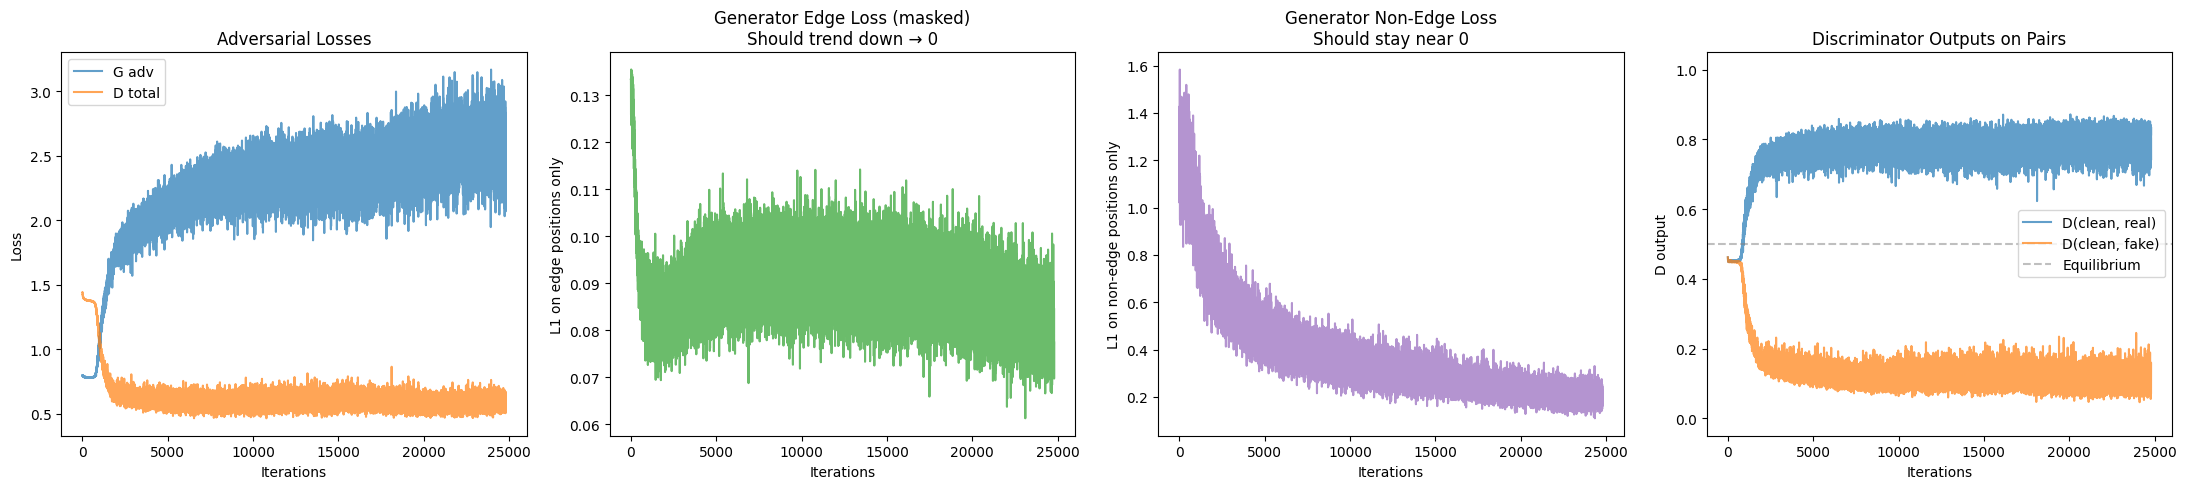

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))  # 4 panels instead of 3

# Panel 1 — adversarial losses (unchanged)
axes[0].set_title('Adversarial Losses')
axes[0].plot(generator_adv_loss_history, label='G adv',   alpha=0.7)
axes[0].plot(discriminator_loss_history, label='D total', alpha=0.7)
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Panel 2 — masked edge loss (the important one — should trend down toward 0)
# This measures how well the generator signals "keep vs remove" on edge positions.
# A decreasing curve means the generator is learning which edges to drop.
axes[1].set_title('Generator Edge Loss (masked)\nShould trend down → 0')
axes[1].plot(generator_edge_loss_history, color='C2', alpha=0.7)
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('L1 on edge positions only')

# Panel 3 — non-edge regularisation loss (should stay near 0 throughout)
# If this rises, the generator is inventing spurious edges on non-edge positions.
axes[2].set_title('Generator Non-Edge Loss\nShould stay near 0')
axes[2].plot(generator_nonedge_loss_history, color='C4', alpha=0.7)
axes[2].set_xlabel('Iterations')
axes[2].set_ylabel('L1 on non-edge positions only')

# Panel 4 — D outputs on real vs fake pairs; equilibrium is 0.5 (unchanged)
axes[3].set_title('Discriminator Outputs on Pairs')
axes[3].plot(discriminator_output_on_real,                 label='D(clean, real)', alpha=0.7)
axes[3].plot(discriminator_output_on_fake_before_g_update, label='D(clean, fake)', alpha=0.7)
axes[3].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Equilibrium')
axes[3].set_xlabel('Iterations')
axes[3].set_ylabel('D output')
axes[3].set_ylim(-0.05, 1.05)
axes[3].legend()

plt.tight_layout()
plt.show()

# 6. Generate Corrupted Graph from Clean Input

We pass the clean adjacency through the trained generator to see what corruption
it produces. Note: we keep the generator in `.train()` mode so dropout stays
active — this is what gives us different corruption samples from the same input
(Pix2Pix convention). Running multiple forward passes gives a distribution.


In [12]:
# Use the dummy KG we already loaded — no need to load a second graph.
# adjacency_tensor: (N, N, R) float32 in {0.0, 1.0}, directed
clean_adjacency_tensor = adjacency_tensor

print(f'Inference graph: {clean_adjacency_tensor.shape}  (N, N, R)')
print(f'Total directed edges: {int(clean_adjacency_tensor.sum())}  across {num_channels} relation channels')
for r in range(num_channels):
    rel_id   = list(relation_id_to_channel.keys())[r]
    rel_name = relation_id_to_name.get(rel_id, f'rel_{r}')
    print(f'  Channel {r} ({rel_name}): {int(clean_adjacency_tensor[:, :, r].sum())} edges')


Inference graph: (10, 10, 3)  (N, N, R)
Total directed edges: 18  across 3 relation channels
  Channel 0 (born_in): 6 edges
  Channel 1 (married_to): 6 edges
  Channel 2 (lives_in): 6 edges


In [13]:
# pix2pix §3.3: run generator in exactly the same manner as training — dropout stays active.
# This makes each forward pass a distinct stochastic sample from the corruption distribution.
generator_model.train()      # dropout ON — stochastic sampling
discriminator_model.eval()   # D is not used at inference

# Convert (N, N, R) → (1, R, N, N) channel-first, rescale to [-1, 1]
clean_tensor_cf = torch.from_numpy(clean_adjacency_tensor).permute(2, 0, 1).unsqueeze(0)  # (1, R, N, N)
clean_input_for_generation = (clean_tensor_cf * 2.0 - 1.0).to(compute_device)

num_samples_to_draw = 5   # draw multiple samples to show stochasticity
generated_samples = []
generated_probs   = []

with torch.no_grad():
    for _ in range(num_samples_to_draw):
        raw_output, raw_prob, _ = generator_model(clean_input_for_generation)
        generated_samples.append(raw_output.cpu().squeeze(0).numpy())   # (R, N, N)
        generated_probs.append(raw_prob.cpu().squeeze(0).numpy())

print(f'Drew {num_samples_to_draw} corruption sample(s)  (each differs due to dropout).')
print(f'Sample 0 output shape: {generated_samples[0].shape}  (R, N, N)')
print(f'Sample 0 prob range:   [{generated_probs[0].min():.3f}, {generated_probs[0].max():.3f}]')

# Verify samples differ across draws (stochasticity check)
if num_samples_to_draw > 1:
    diffs = [abs(generated_samples[i] - generated_samples[0]).mean() for i in range(1, num_samples_to_draw)]
    print(f'Mean absolute difference between sample 0 and samples 1-{num_samples_to_draw-1}: '
          f'{[f"{d:.4f}" for d in diffs]}  (non-zero = stochastic)')


Drew 5 corruption sample(s)  (each differs due to dropout).
Sample 0 output shape: (3, 10, 10)  (R, N, N)
Sample 0 prob range:   [0.000, 1.000]
Mean absolute difference between sample 0 and samples 1-4: ['0.0074', '0.0122', '0.0043', '0.0145']  (non-zero = stochastic)


In [14]:
def postprocess_threshold(raw_output_rnxn, threshold=0.5):
    """Binarise a (R, N, N) generator output (in [-1,1]) to {0,1}.

    Returns (prob, binary) both shape (R, N, N).
    Diagonal is forced to zero on all channels — no self-loops.
    """
    prob   = (raw_output_rnxn + 1.0) / 2.0
    binary = (prob > threshold).astype(float)
    for r in range(binary.shape[0]):
        np.fill_diagonal(binary[r], 0)
    return prob, binary


binarisation_threshold = 0.5
processed_samples_threshold = [
    postprocess_threshold(s, binarisation_threshold) for s in generated_samples
]

gen_prob, gen_binary  = processed_samples_threshold[0]
clean_total_edges     = int(clean_adjacency_tensor.sum())
gen_total_edges       = int(gen_binary.sum())
edge_delta            = gen_total_edges - clean_total_edges

print(f'Clean graph total edges (all channels):     {clean_total_edges}')
print(f'GAN output total edges (threshold={binarisation_threshold}): {gen_total_edges}')
print(f'Edge delta (should be ~0 — change_relation keeps total count): {edge_delta:+d}')
print()

# Per-channel breakdown reveals which relations the GAN shifted edges into/out of
relation_names = [relation_id_to_name[rid]
                  for rid in sorted(relation_id_to_channel, key=relation_id_to_channel.get)]
for r in range(num_channels):
    clean_r = int(clean_adjacency_tensor[:, :, r].sum())
    gen_r   = int(gen_binary[r].sum())
    print(f'  Channel {r} ({relation_names[r]}): {clean_r} clean → {gen_r} generated  (delta: {gen_r - clean_r:+d})')


Clean graph total edges (all channels):     18
GAN output total edges (threshold=0.5): 18
Edge delta (should be ~0 — change_relation keeps total count): +0

  Channel 0 (born_in): 6 clean → 5 generated  (delta: -1)
  Channel 1 (married_to): 6 clean → 7 generated  (delta: +1)
  Channel 2 (lives_in): 6 clean → 6 generated  (delta: +0)


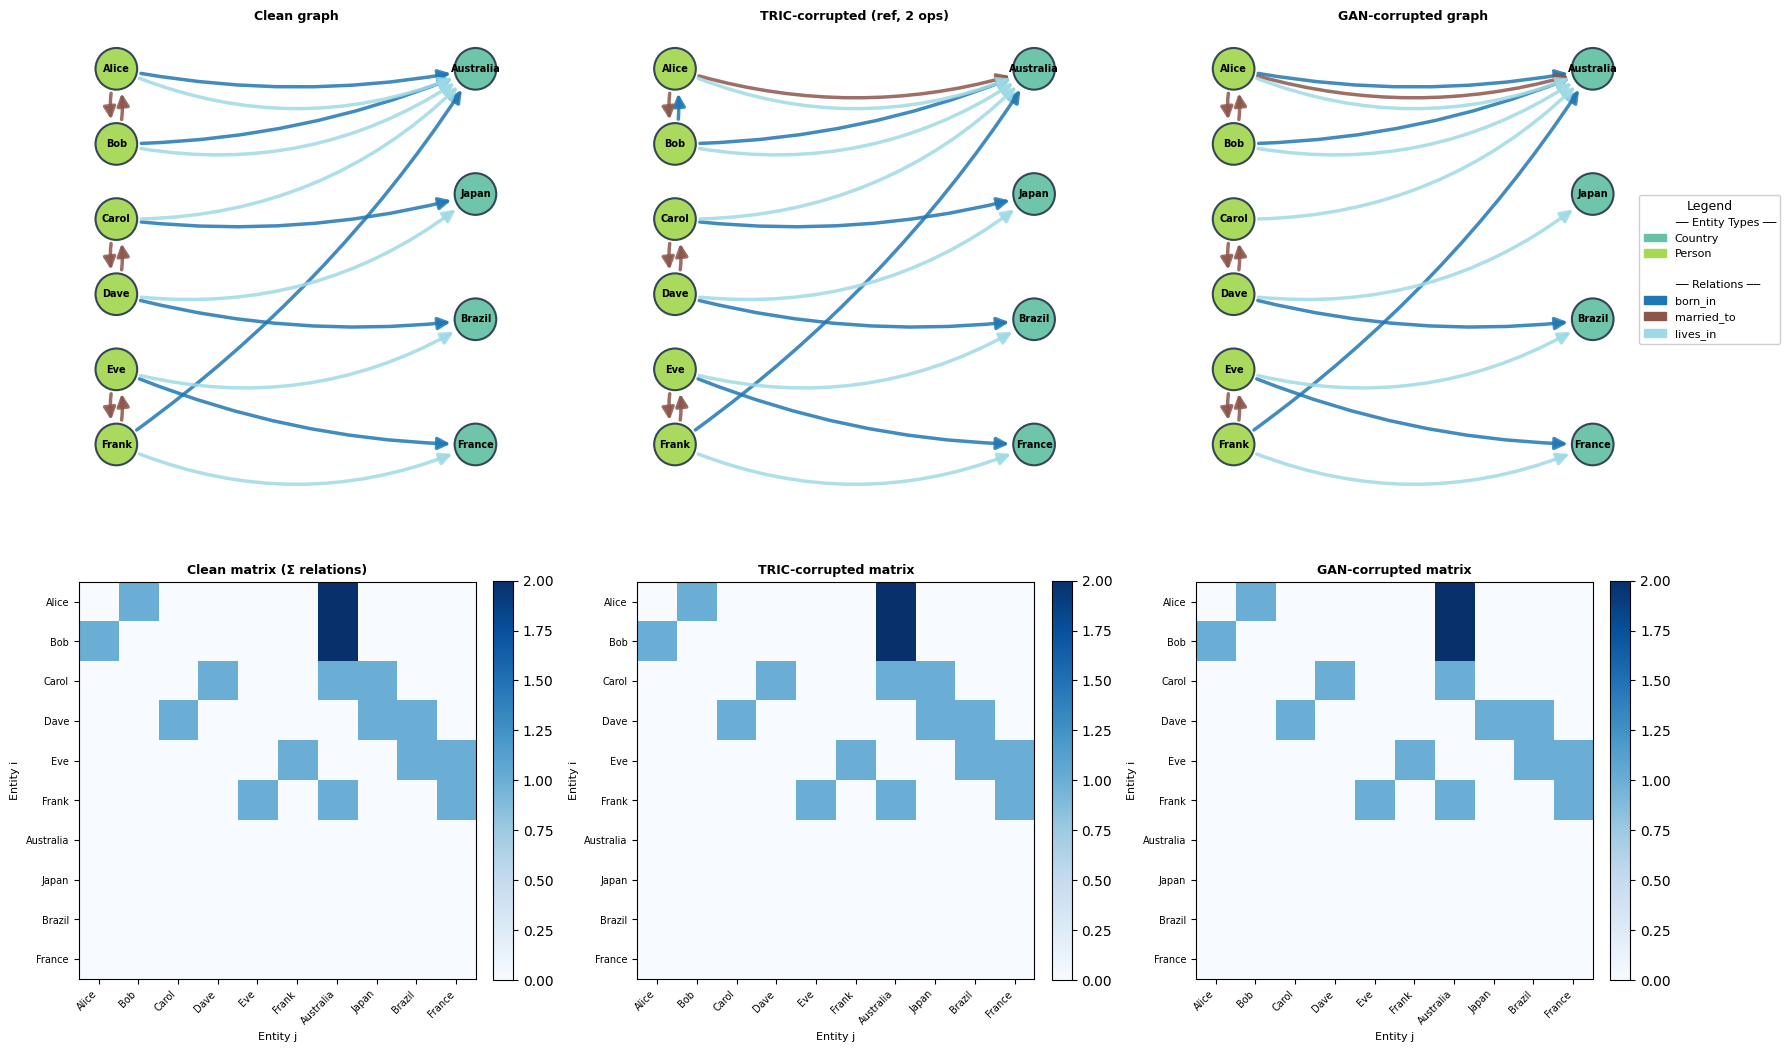

In [15]:
import functools
from corruption_strategies import apply_tric_corruption
from visualisation import plot_gan_comparison

# Reference corruption uses the same strategy as training (change_relation only)
# so the comparison is fair — both GAN and rule apply the same operation.
rule_rng    = np.random.default_rng(999)
tric_ref_fn = functools.partial(apply_tric_corruption, node_types=node_types,
                                op_weights={'change_relation': 1})
rule_corrupted_nxnxr = tric_ref_fn(clean_adjacency_tensor, num_corruptions, rule_rng)  # (N, N, R)

# GAN output: gen_binary is (R, N, N) from postprocess_threshold — convert to (N, N, R)
gen_prob, gen_binary = processed_samples_threshold[0]
gan_nxnxr = gen_binary.transpose(1, 2, 0)   # (N, N, R)

relation_names = [relation_id_to_name[rid]
                  for rid in sorted(relation_id_to_channel, key=relation_id_to_channel.get)]

plot_gan_comparison(
    clean_adjacency_tensor, rule_corrupted_nxnxr, gan_nxnxr,
    node_labels, node_types,
    relation_names, num_corruptions=num_corruptions,
)


# 7. Validation: Does the GAN Match the Corruption Distribution?

A proof-of-concept conditional GAN should reproduce the *statistical distribution*
of the rule, not just one sample. We compare relation-shift counts across many
draws from the GAN vs many draws from the rule.

`change_relation` swaps an edge from one relation channel to another — the total
edge count stays constant, but the per-channel distribution shifts. A well-trained
GAN should shift roughly `num_corruptions` edges per sample (matching the rule)
with a net edge delta near zero. Systematic deviation (e.g., GAN shifts 0 edges
every time) indicates the model is not learning to swap relations.


In [16]:
import functools
from corruption_strategies import apply_tric_corruption

num_validation_samples = 200
rule_shifted_counts = []   # edges that changed channel in rule output
gan_shifted_counts  = []   # edges that changed channel in GAN output
gan_net_delta       = []   # total edge count change in GAN output (should be ~0)

# channel-first view of the clean adjacency for direct comparison with gen_binary
clean_cf_np = clean_adjacency_tensor.transpose(2, 0, 1)   # (R, N, N)

# Reference uses the same strategy as training — change_relation only
tric_val_fn    = functools.partial(apply_tric_corruption, node_types=node_types,
                                   op_weights={'change_relation': 1})
validation_rng = np.random.default_rng(12345)
generator_model.train()   # keep dropout active to sample from the GAN distribution

with torch.no_grad():
    for _ in range(num_validation_samples):
        # Rule corruption — identical strategy to training
        rule_corr = tric_val_fn(clean_adjacency_tensor, num_corruptions, validation_rng)
        # Edges that left their original channel (= num_corruptions when no op skips)
        rule_shifted_counts.append(int(((clean_adjacency_tensor - rule_corr) > 0.5).sum()))

        # GAN corruption
        raw_t, _, _ = generator_model(clean_input_for_generation)
        raw_np      = raw_t.cpu().squeeze(0).numpy()   # (R, N, N)
        _, gan_bin  = postprocess_threshold(raw_np, binarisation_threshold)

        # Edges that left their original channel in the GAN output
        gan_shifted_counts.append(int(((clean_cf_np - gan_bin) > 0.5).sum()))
        # Net change in total edges — should be ~0 for change_relation
        gan_net_delta.append(int(gan_bin.sum()) - int(clean_cf_np.sum()))

rule_shifted_counts = np.array(rule_shifted_counts)
gan_shifted_counts  = np.array(gan_shifted_counts)
gan_net_delta       = np.array(gan_net_delta)

print(f'Over {num_validation_samples} samples:')
print(f'  Rule - edges shifted channel: mean={rule_shifted_counts.mean():5.1f}, std={rule_shifted_counts.std():.2f}  (expect ~{num_corruptions})')
print(f'  GAN  - edges shifted channel: mean={gan_shifted_counts.mean():5.1f},  std={gan_shifted_counts.std():.2f}')
print(f'  GAN  - net edge delta:        mean={gan_net_delta.mean():+.2f}, std={gan_net_delta.std():.2f}  (expect ~0)')


Over 200 samples:
  Rule - edges shifted channel: mean=  1.9, std=0.40  (expect ~2)
  GAN  - edges shifted channel: mean=  1.0,  std=0.79
  GAN  - net edge delta:        mean=+0.06, std=0.68  (expect ~0)


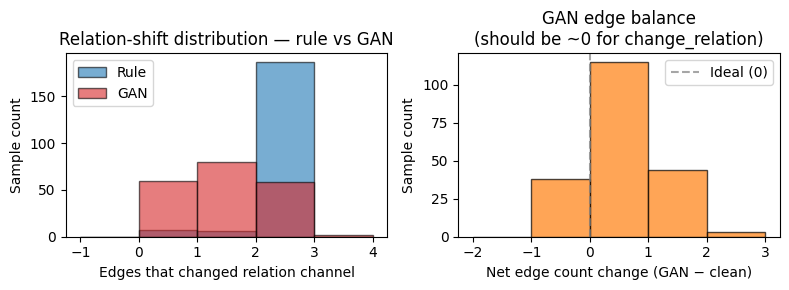

In [17]:
# Side-by-side: relation-shift distribution (rule vs GAN) and GAN net edge balance
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

bin_edges = np.arange(
    min(rule_shifted_counts.min(), gan_shifted_counts.min()) - 1,
    max(rule_shifted_counts.max(), gan_shifted_counts.max()) + 2
)

axes[0].hist(rule_shifted_counts, bins=bin_edges, alpha=0.6, label='Rule', color='C0', edgecolor='black')
axes[0].hist(gan_shifted_counts,  bins=bin_edges, alpha=0.6, label='GAN',  color='C3', edgecolor='black')
axes[0].set_xlabel('Edges that changed relation channel')
axes[0].set_ylabel('Sample count')
axes[0].set_title('Relation-shift distribution — rule vs GAN')
axes[0].legend()

delta_bins = np.arange(gan_net_delta.min() - 1, gan_net_delta.max() + 2)
axes[1].hist(gan_net_delta, bins=delta_bins, alpha=0.7, color='C1', edgecolor='black')
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.7, label='Ideal (0)')
axes[1].set_xlabel('Net edge count change (GAN − clean)')
axes[1].set_ylabel('Sample count')
axes[1].set_title('GAN edge balance\n(should be ~0 for change_relation)')
axes[1].legend()

plt.tight_layout()
plt.show()
